# IMPORT LIBRARIES

In [1]:
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# IMPORT DATA

In [2]:
# Percorso file
file_path = r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results\demo_clustered_seed1.json"

# Lettura JSON
with open(file_path, "r") as f:
    data = json.load(f)

print(data.keys()) 

dict_keys(['objective_value', 'variables'])


# ANALYZE

## OBJECTIVE FUNCTIONS

In [3]:
data['objective_value']

61.27842

In [4]:
data['variables']

{'start': {'t7|k1|18': 1.0,
  't2|k1|2': 1.0,
  't5|k2|26': 1.0,
  't9|k3|5': 1.0,
  't10|k4|18': 1.0,
  't4|k2|10': 1.0,
  't6|k3|17': 1.0,
  't8|k3|20': 1.0,
  't3|k1|19': 1.0,
  't1|k4|12': 1.0},
 'z': {'t7|k1|18': 1.0,
  't2|k1|2': 1.0,
  't2|k1|3': 1.0,
  't2|k1|4': 1.0,
  't5|k2|26': 1.0,
  't5|k2|27': 1.0,
  't5|k2|28': 1.0,
  't5|k2|29': 1.0,
  't5|k2|30': 1.0,
  't9|k3|5': 1.0,
  't9|k3|6': 1.0,
  't10|k4|18': 1.0,
  't10|k4|19': 1.0,
  't10|k4|20': 1.0,
  't4|k2|10': 1.0,
  't4|k2|11': 1.0,
  't4|k2|12': 1.0,
  't4|k2|13': 1.0,
  't6|k3|17': 1.0,
  't6|k3|18': 1.0,
  't8|k3|20': 1.0,
  't3|k1|19': 1.0,
  't3|k1|20': 1.0,
  't3|k1|21': 1.0,
  't1|k4|12': 1.0,
  't1|k4|13': 1.0,
  't1|k4|14': 1.0},
 'loc': {'p3|k3|20': 1.0,
  'p3|k3|21': 1.0,
  'b2|k2|1': 1.0,
  'b2|k2|2': 1.0,
  'b2|k2|3': 1.0,
  'b2|k2|4': 1.0,
  'b2|k2|5': 1.0,
  'b2|k2|6': 1.0,
  'b2|k2|7': 1.0,
  'b2|k2|8': 1.0,
  'b2|k2|9': 1.0,
  'b2|k2|15': 1.0,
  'b2|k2|16': 1.0,
  'b2|k2|17': 1.0,
  'b2|k2|18': 1.0,
 

In [5]:
# -----------------------------
# Paths
# -----------------------------
INPUT_PATH   = r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances\demo_clustered_seed1.json"
RESULTS_PATH = r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results\demo_clustered_seed1.json"

## TRAVEL MODE

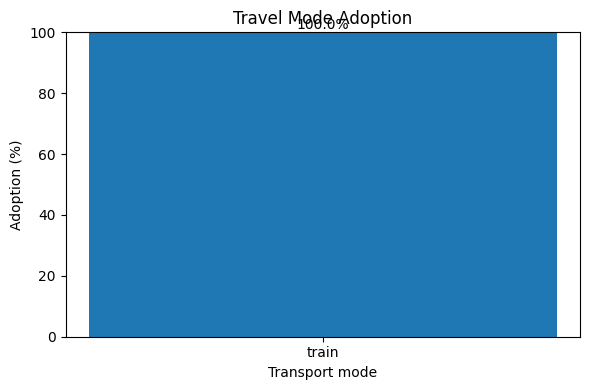

In [13]:
import json
from collections import Counter
import matplotlib.pyplot as plt

# -----------------------------
# LOAD RESULTS
# -----------------------------
with open(RESULTS_PATH, "r") as f:
    res = json.load(f)

y = res["variables"]["y"]

# -----------------------------
# COUNT TRIPS PER MODE
# -----------------------------
mode_count = Counter()

for key, val in y.items():
    if val > 0.5:  # active trip
        parts = key.split("|")
        mode = parts[-1]
        mode_count[mode] += 1

total_trips = sum(mode_count.values())

# -----------------------------
# COMPUTE PERCENTAGES
# -----------------------------
modes = list(mode_count.keys())
percentages = [100 * mode_count[m] / total_trips for m in modes]

# -----------------------------
# BARPLOT
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(modes, percentages)

plt.ylabel("Adoption (%)")
plt.xlabel("Transport mode")
plt.title("Travel Mode Adoption")
plt.ylim(0,100)

# show percentage labels
for i, v in enumerate(percentages):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

## SCHEDULING

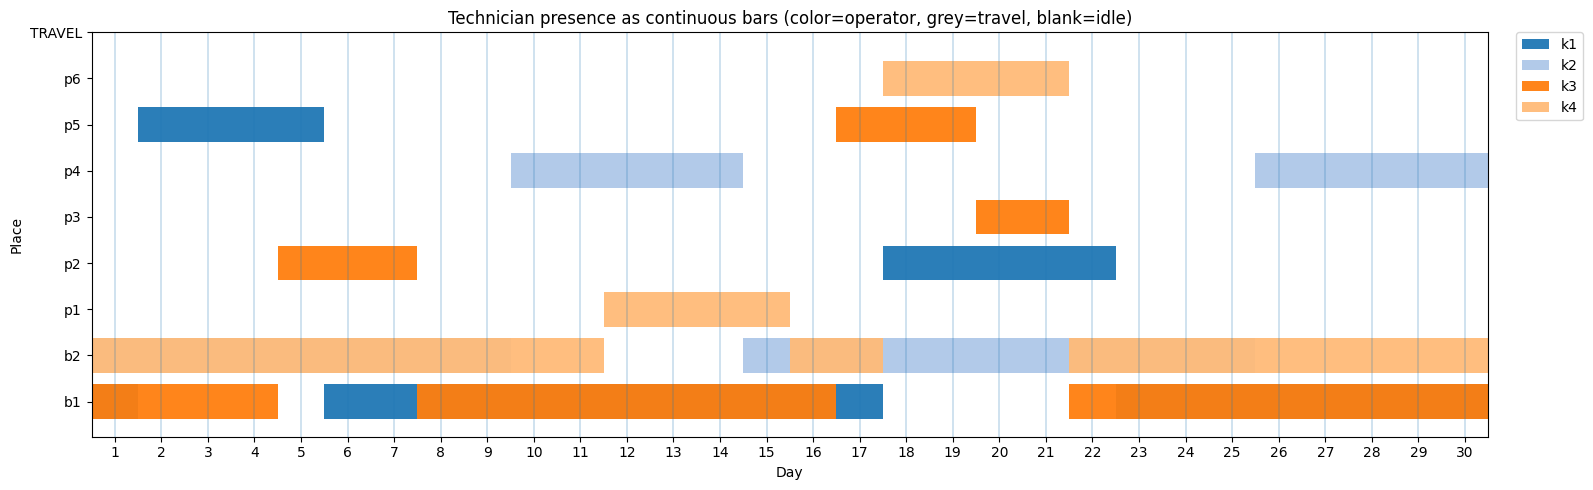

In [6]:
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt


def parse_key(key: str):
    # loc:  "p17|k6|14"
    # away: "k6|14"
    # z:    "t10|k2|21"
    return key.split("|")

# ----------------------------
# Read results
# ----------------------------
with open(RESULTS_PATH, "r") as f:
    res = json.load(f)

vars_ = res["variables"]
loc = vars_.get("loc", {})     # place|k|d -> 1
away = vars_.get("away", {})   # k|d -> 1
z = vars_.get("z", {})         # t|k|d -> 1

# ----------------------------
# Build day/operator/place/status table (one row per operator-day)
# ----------------------------
place_by_kd = {}
away_set = set()
work_set = set()

all_days = set()
all_ops = set()
all_places = set()

# loc: place for (k,d)
for key, val in loc.items():
    if float(val) <= 0:
        continue
    p, k, d = parse_key(key)
    d = int(d)
    place_by_kd[(k, d)] = p
    all_days.add(d)
    all_ops.add(k)
    all_places.add(p)

# away: (k,d)
for key, val in away.items():
    if float(val) <= 0:
        continue
    k, d = parse_key(key)
    d = int(d)
    away_set.add((k, d))
    all_days.add(d)
    all_ops.add(k)

# z: working if any ticket assigned that day
for key, val in z.items():
    if float(val) <= 0:
        continue
    _t, k, d = parse_key(key)
    d = int(d)
    work_set.add((k, d))
    all_days.add(d)
    all_ops.add(k)

if not all_days or not all_ops:
    raise ValueError("No days/operators found in results (loc/away/z all empty?)")

d_min, d_max = min(all_days), max(all_days)
days = list(range(d_min, d_max + 1))      # show ALL day numbers continuously
ops = sorted(all_ops)

# sort places (bases first if 'b*', then plants 'p*')
places = sorted(all_places, key=lambda x: (0 if str(x).startswith("b") else 1, str(x)))

rows = []
for k in ops:
    for d in days:
        p = place_by_kd.get((k, d), None)
        is_away = (k, d) in away_set
        is_work = (k, d) in work_set

        # your rule: grey if travelling for some days; blank if doing nothing
        # -> TRAVEL when away==1 and not working (even if no explicit location)
        # -> ON_SITE when a location exists (color by operator)
        # -> IDLE when neither location nor travel
        if p is not None:
            status = "ON_SITE"
        elif is_away and (not is_work):
            status = "TRAVEL"
        else:
            status = "IDLE"

        rows.append({"operator": k, "day": d, "place": p, "away": is_away, "work": is_work, "status": status})

df = pd.DataFrame(rows)

# ----------------------------
# Convert operator-day statuses to continuous segments (bars)
# - ON_SITE segments are placed on the y-row of that place
# - TRAVEL segments are placed on a dedicated y-row "TRAVEL"
# - IDLE has no bar (blank)
# ----------------------------
place_to_y = {p: i for i, p in enumerate(places)}
travel_y = len(places)  # put TRAVEL row at bottom/top; we’ll label it

def iter_segments_for_operator(k: str):
    g = df[df["operator"] == k].sort_values("day")

    segments = []
    cur_kind = None        # "ON_SITE" / "TRAVEL" / "IDLE"
    cur_place = None       # only for ON_SITE
    start_day = None

    def close_segment(end_day_inclusive):
        nonlocal segments, cur_kind, cur_place, start_day
        if cur_kind in (None, "IDLE"):
            return
        length = end_day_inclusive - start_day + 1
        if cur_kind == "TRAVEL":
            segments.append(("TRAVEL", None, start_day, length))
        elif cur_kind == "ON_SITE":
            segments.append(("ON_SITE", cur_place, start_day, length))

    for _, r in g.iterrows():
        d = int(r["day"])
        kind = r["status"]
        pl = r["place"] if kind == "ON_SITE" else None

        if cur_kind is None:
            cur_kind, cur_place, start_day = kind, pl, d
            continue

        # continuity condition:
        # - ON_SITE continues only if same place
        # - TRAVEL continues while TRAVEL
        # - IDLE continues while IDLE (but we don't draw it)
        same = (kind == cur_kind) and ((kind != "ON_SITE") or (pl == cur_place))

        if same:
            continue

        # segment break
        close_segment(d - 1)
        cur_kind, cur_place, start_day = kind, pl, d

    # close last
    close_segment(int(g["day"].max()))
    return segments

# Stable colors per operator
cmap = plt.get_cmap("tab20")
op_to_color = {k: cmap(i % 20) for i, k in enumerate(ops)}

fig, ax = plt.subplots(figsize=(16, max(5, (len(places) + 1) * 0.35)))

bar_h = 0.75
for k in ops:
    segs = iter_segments_for_operator(k)
    for kind, pl, start, length in segs:
        if kind == "TRAVEL":
            y = travel_y
            ax.barh(
                y=y,
                width=length,
                left=start - 0.5,          # align to day-cells
                height=bar_h,
                color="grey",
                edgecolor="none",
                alpha=0.9,
            )
        else:  # ON_SITE
            y = place_to_y[pl]
            ax.barh(
                y=y,
                width=length,
                left=start - 0.5,
                height=bar_h,
                color=op_to_color[k],
                edgecolor="none",
                alpha=0.95,
                label=k,  # will be deduped later
            )

# ----------------------------
# Axis: show all days + vertical lines each day
# ----------------------------
ax.set_xlim(d_min - 0.5, d_max + 0.5)
ax.set_xticks(days)  # show ALL day numbers
ax.set_xlabel("Day")
ax.set_ylabel("Place")

# vertical line every day boundary
for d in range(d_min, d_max + 1):
    ax.axvline(d, linewidth=0.3)

# y labels (places + travel)
y_ticks = list(range(len(places))) + [travel_y]
y_labels = places + ["TRAVEL"]
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)

ax.set_title("Technician presence as continuous bars (color=operator, grey=travel, blank=idle)")

# Deduplicate legend entries (since we add label multiple times)
handles, labels = ax.get_legend_handles_labels()
seen = set()
h2, l2 = [], []
for h, lab in zip(handles, labels):
    if lab in seen:
        continue
    seen.add(lab)
    h2.append(h)
    l2.append(lab)

ax.legend(h2, l2, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)

plt.tight_layout()
plt.show()

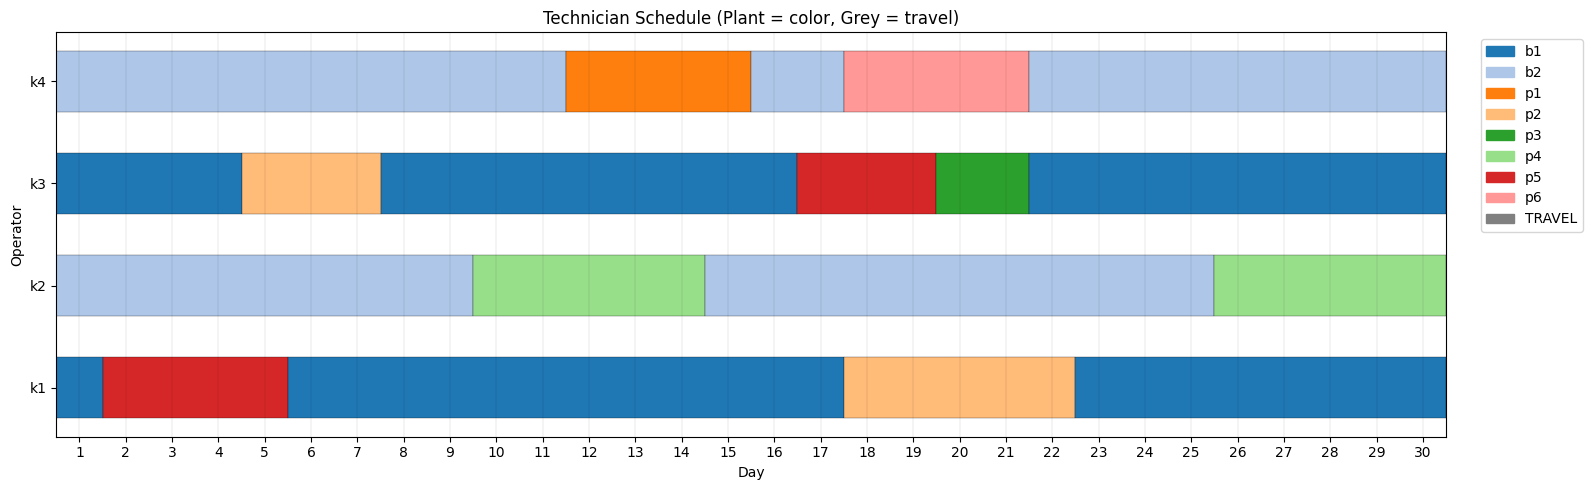

In [7]:
def parse_key(key: str):
    return key.split("|")

# --------------------------------------------------
# LOAD RESULTS
# --------------------------------------------------
with open(RESULTS_PATH, "r") as f:
    res = json.load(f)

vars_ = res["variables"]
loc = vars_.get("loc", {})
away = vars_.get("away", {})
z = vars_.get("z", {})

place_by_kd = {}
away_set = set()
work_set = set()

all_days = set()
all_ops = set()
all_places = set()

# --- location
for key, val in loc.items():
    if float(val) <= 0:
        continue
    p, k, d = parse_key(key)
    d = int(d)
    place_by_kd[(k, d)] = p
    all_days.add(d)
    all_ops.add(k)
    all_places.add(p)

# --- away
for key, val in away.items():
    if float(val) <= 0:
        continue
    k, d = parse_key(key)
    d = int(d)
    away_set.add((k, d))
    all_days.add(d)
    all_ops.add(k)

# --- working
for key, val in z.items():
    if float(val) <= 0:
        continue
    _, k, d = parse_key(key)
    d = int(d)
    work_set.add((k, d))
    all_days.add(d)
    all_ops.add(k)

if not all_days:
    raise ValueError("No scheduling data found.")

d_min, d_max = min(all_days), max(all_days)
days = list(range(d_min, d_max + 1))
ops = sorted(all_ops)
plants = sorted(all_places)

# --------------------------------------------------
# BUILD FULL OPERATOR-DAY TABLE
# --------------------------------------------------
rows = []

for k in ops:
    for d in days:
        p = place_by_kd.get((k, d))
        is_away = (k, d) in away_set
        is_work = (k, d) in work_set

        if p is not None:
            status = "ON_SITE"
        elif is_away and not is_work:
            status = "TRAVEL"
        else:
            status = "IDLE"

        rows.append({
            "operator": k,
            "day": d,
            "plant": p,
            "status": status
        })

df = pd.DataFrame(rows)

# --------------------------------------------------
# BUILD CONTINUOUS SEGMENTS (for Gantt bars)
# --------------------------------------------------
def build_segments(operator):
    g = df[df["operator"] == operator].sort_values("day")

    segments = []
    cur_status = None
    cur_plant = None
    start_day = None

    def close_segment(end_day):
        if cur_status in ("ON_SITE", "TRAVEL"):
            segments.append({
                "operator": operator,
                "status": cur_status,
                "plant": cur_plant,
                "start": start_day,
                "length": end_day - start_day + 1
            })

    for _, r in g.iterrows():
        d = r["day"]
        status = r["status"]
        plant = r["plant"]

        if cur_status is None:
            cur_status = status
            cur_plant = plant
            start_day = d
            continue

        same = (
            status == cur_status and
            (status != "ON_SITE" or plant == cur_plant)
        )

        if same:
            continue

        close_segment(d - 1)
        cur_status = status
        cur_plant = plant
        start_day = d

    close_segment(g["day"].max())
    return segments

all_segments = []
for k in ops:
    all_segments.extend(build_segments(k))

segments_df = pd.DataFrame(all_segments)

# --------------------------------------------------
# COLOR MAP FOR PLANTS (Hue = Plant)
# --------------------------------------------------
cmap = plt.get_cmap("tab20")
plant_to_color = {p: cmap(i % 20) for i, p in enumerate(plants)}

# --------------------------------------------------
# PLOT GANTT (Operator on Y axis)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(16, max(5, len(ops) * 0.6)))

op_to_y = {k: i for i, k in enumerate(ops)}
bar_height = 0.6

for _, seg in segments_df.iterrows():
    y = op_to_y[seg["operator"]]

    if seg["status"] == "TRAVEL":
        color = "grey"
    else:
        color = plant_to_color[seg["plant"]]

    ax.barh(
        y=y,
        width=seg["length"],
        left=seg["start"] - 0.5,
        height=bar_height,
        color=color,
        edgecolor="black",
        linewidth=0.2
    )

# --------------------------------------------------
# AXIS FORMAT
# --------------------------------------------------
ax.set_yticks(list(op_to_y.values()))
ax.set_yticklabels(ops)

ax.set_xlim(d_min - 0.5, d_max + 0.5)
ax.set_xticks(days)  # show ALL days
ax.set_xlabel("Day")
ax.set_ylabel("Operator")
ax.set_title("Technician Schedule (Plant = color, Grey = travel)")

# vertical gridlines each day
for d in days:
    ax.axvline(d, linewidth=0.3, color="black", alpha=0.2)

# --------------------------------------------------
# LEGEND (plants + travel)
# --------------------------------------------------
handles = []
labels = []

for p, c in plant_to_color.items():
    handles.append(plt.Rectangle((0,0),1,1,color=c))
    labels.append(p)

handles.append(plt.Rectangle((0,0),1,1,color="grey"))
labels.append("TRAVEL")

ax.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

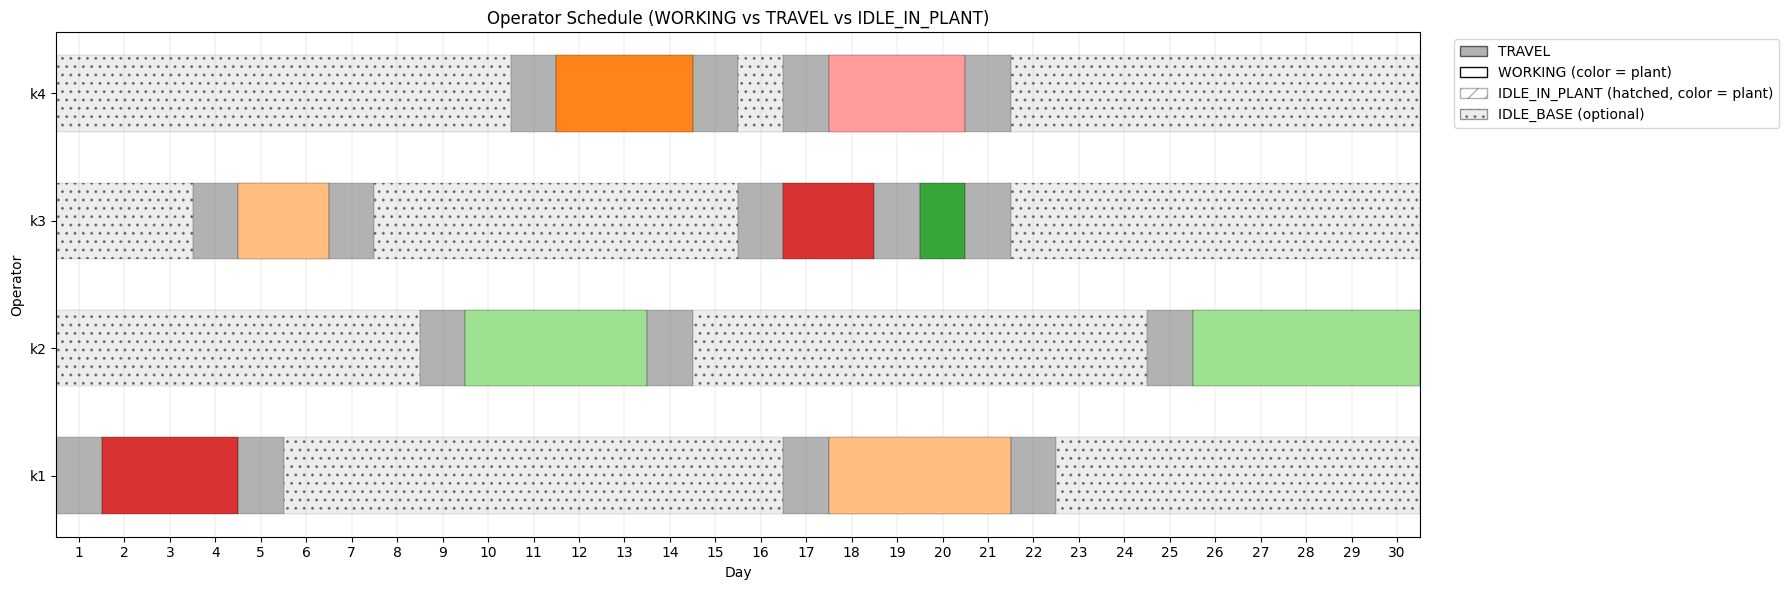

In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# INPUT_PATH   = "data/demo_input.json"
# RESULTS_PATH = "results/demo_clustered_seed1.json"

# -----------------------------
# HELPERS
# -----------------------------
def parse_key(key: str):
    return key.split("|")

# -----------------------------
# LOAD RESULTS (schedule vars)
# -----------------------------
with open(RESULTS_PATH, "r") as f:
    res = json.load(f)

vars_ = res.get("variables", {})
loc   = vars_.get("loc", {})     # n|k|d -> 1
z     = vars_.get("z", {})       # t|k|d -> 1
y     = vars_.get("y", {})       # i|j|k|d|m -> 1  (travel departures)

if not loc:
    raise ValueError("No 'loc' variable found in results. Cannot plot operator locations.")

# -----------------------------
# BUILD OPERATOR-DAY TABLE
#   Distinguish:
#     - WORKING (on-site + z=1)
#     - IDLE_IN_PLANT (on-site + z=0)
#     - TRAVEL (y=1 that day)
#     - IDLE_BASE (at base, not working, not traveling)  [optional but useful]
# -----------------------------
place_by_kd = {}      # (k,d) -> node
work_set = set()      # (k,d)
travel_set = set()    # (k,d)

all_days = set()
all_ops = set()
all_places = set()

# location
for key, val in loc.items():
    if float(val) <= 0:
        continue
    n, k, d = parse_key(key)
    d = int(d)
    place_by_kd[(k, d)] = n
    all_days.add(d)
    all_ops.add(k)
    all_places.add(n)

# working (z)
for key, val in z.items():
    if float(val) <= 0:
        continue
    _, k, d = parse_key(key)
    d = int(d)
    work_set.add((k, d))
    all_days.add(d)
    all_ops.add(k)

# travel (y departures)
for key, val in y.items():
    if float(val) <= 0:
        continue
    i, j, k, d, md = parse_key(key)
    d = int(d)
    travel_set.add((k, d))
    all_days.add(d)
    all_ops.add(k)

if not all_days or not all_ops:
    raise ValueError("No scheduling data found (loc/z/y empty or all zeros).")

d_min, d_max = min(all_days), max(all_days)
days = list(range(d_min, d_max + 1))
ops = sorted(all_ops)
plants = sorted(all_places)

rows = []
for k in ops:
    for d in days:
        n = place_by_kd.get((k, d))
        is_work = (k, d) in work_set
        is_travel = (k, d) in travel_set

        # In your model (atomic day), travel and work should not overlap,
        # but we still prioritize TRAVEL if it happens.
        if n is None:
            status = "UNKNOWN"
        elif is_travel:
            status = "TRAVEL"
        elif is_work:
            status = "WORKING"
        else:
            # idle while physically at some node (plant/base/customer)
            # label specifically as "IDLE_IN_PLANT" (requested) and keep "IDLE_BASE" separate for clarity
            if str(n).lower().startswith("b") or str(n).lower().startswith("base"):
                status = "IDLE_BASE"
            else:
                status = "IDLE_IN_PLANT"

        rows.append({"operator": k, "day": d, "plant": n, "status": status})

df_sched = pd.DataFrame(rows)

# -----------------------------
# CONTINUOUS SEGMENTS FOR GANTT
# -----------------------------
def build_segments(operator):
    g = df_sched[df_sched["operator"] == operator].sort_values("day")
    segments = []
    cur_status = None
    cur_plant = None
    start_day = None

    def close_segment(end_day):
        if cur_status in ("WORKING", "IDLE_IN_PLANT", "IDLE_BASE", "TRAVEL"):
            segments.append({
                "operator": operator,
                "status": cur_status,
                "plant": cur_plant,
                "start": start_day,
                "length": end_day - start_day + 1
            })

    for _, r in g.iterrows():
        d = int(r["day"])
        status = r["status"]
        plant = r["plant"]

        if cur_status is None:
            cur_status = status
            cur_plant = plant
            start_day = d
            continue

        same = (
            status == cur_status
            and (status in ("TRAVEL",) or plant == cur_plant)  # for non-travel, keep segment only if same node
        )

        if same:
            continue

        close_segment(d - 1)
        cur_status = status
        cur_plant = plant
        start_day = d

    close_segment(int(g["day"].max()))
    return segments

segments = []
for k in ops:
    segments.extend(build_segments(k))
segments_df = pd.DataFrame(segments)

# -----------------------------
# COLORS (plants)
# -----------------------------
cmap = plt.get_cmap("tab20")
plant_to_color = {p: cmap(i % 20) for i, p in enumerate(plants)}

# -----------------------------
# PLOT (NO ticket windows)
# -----------------------------
fig, ax = plt.subplots(figsize=(18, max(6, len(ops) * 0.7)))
op_to_y = {k: i for i, k in enumerate(ops)}

schedule_h = 0.60
for _, seg in segments_df.iterrows():
    yrow = op_to_y[seg["operator"]]

    status = seg["status"]
    plant = seg["plant"]

    # Styling by status:
    # - WORKING: solid plant color
    # - IDLE_IN_PLANT: same plant color but hatched + lighter
    # - TRAVEL: grey
    # - IDLE_BASE: light grey + hatch
    if status == "TRAVEL":
        facecolor = "grey"
        alpha = 0.6
        hatch = None
    elif status == "WORKING":
        facecolor = plant_to_color.get(plant, "lightgrey")
        alpha = 0.95
        hatch = None
    elif status == "IDLE_IN_PLANT":
        facecolor = plant_to_color.get(plant, "lightgrey")
        alpha = 0.30
        hatch = "//"
    elif status == "IDLE_BASE":
        facecolor = "lightgrey"
        alpha = 0.40
        hatch = ".."
    else:
        facecolor = "white"
        alpha = 0.20
        hatch = "xx"

    ax.barh(
        y=yrow,
        width=seg["length"],
        left=seg["start"] - 0.5,
        height=schedule_h,
        color=facecolor,
        alpha=alpha,
        edgecolor="black",
        linewidth=0.2,
        hatch=hatch,
        zorder=1
    )

# -----------------------------
# AXIS + GRID
# -----------------------------
ax.set_yticks(list(op_to_y.values()))
ax.set_yticklabels(ops)

ax.set_xlim(d_min - 0.5, d_max + 0.5)
ax.set_xticks(days)
ax.set_xlabel("Day")
ax.set_ylabel("Operator")
ax.set_title("Operator Schedule (WORKING vs TRAVEL vs IDLE_IN_PLANT)")

for d in days:
    ax.axvline(d, linewidth=0.3, color="black", alpha=0.2, zorder=0)

# -----------------------------
# LEGEND
# -----------------------------
handles = []
labels = []

# Status legend (compact)
handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="grey", edgecolor="black", alpha=0.6))
labels.append("TRAVEL")

handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="black", alpha=0.95))
labels.append("WORKING (color = plant)")

handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="black", alpha=0.30, hatch="//"))
labels.append("IDLE_IN_PLANT (hatched, color = plant)")

handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="lightgrey", edgecolor="black", alpha=0.40, hatch=".."))
labels.append("IDLE_BASE (optional)")

# Plant color key (optional: uncomment if you want a full plant list legend)
# for p, c in plant_to_color.items():
#     handles.append(plt.Rectangle((0, 0), 1, 1, facecolor=c, edgecolor="black", linewidth=0.2))
#     labels.append(f"Plant: {p}")

ax.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [9]:
import json
import pandas as pd

# INPUT_PATH   = "data/demo_input.json"
# RESULTS_PATH = "results/demo_clustered_seed1.json"

def parse_key(key: str):
    return key.split("|")

def get_ticket_param(data, name, t, default=None):
    """
    Robust getter for ticket parameters.
    Supports:
      - data[name] is dict keyed by ticket
      - data[name] is scalar (same for all tickets)
      - missing -> default
    """
    if name not in data:
        return default
    obj = data[name]
    if isinstance(obj, dict):
        return obj.get(t, default)
    return obj

# -----------------------------
# LOAD INPUT (a,b,dur,node,w)
# -----------------------------
with open(INPUT_PATH, "r") as f:
    data = json.load(f)

tickets = list(data["T"])

df_in = pd.DataFrame({
    "ticket": tickets,
    "release_a": [int(get_ticket_param(data, "a", t)) for t in tickets],
    "deadline_b": [int(get_ticket_param(data, "b", t)) for t in tickets],
    "dur_input":  [get_ticket_param(data, "dur",  t, default=None) for t in tickets],
    "plant":      [get_ticket_param(data, "node", t, default=None) for t in tickets],
    "weight":     [float(get_ticket_param(data, "w", t, default=1.0)) for t in tickets],
})
df_in["dur_input"] = pd.to_numeric(df_in["dur_input"], errors="coerce")

# -----------------------------
# LOAD RESULTS (z, start)
# -----------------------------
with open(RESULTS_PATH, "r") as f:
    res = json.load(f)

vars_ = res.get("variables", {})
z = vars_.get("z", {})           # t|k|d -> 1
start = vars_.get("start", {})   # t|k|d -> 1

if not z and not start:
    raise ValueError("Results file has neither 'z' nor 'start'.")

# -----------------------------
# BUILD PER-TICKET STATS FROM z/start
# -----------------------------
# From z: days worked, first day worked, last day worked, and which operator worked
worked_days_by_t = {}        # t -> set(days)
first_z_day_by_t = {}        # t -> min day with any work
last_z_day_by_t = {}         # t -> max day with any work
ops_from_z_by_t = {}         # t -> set(operators)

for key, val in z.items():
    if float(val) <= 0:
        continue
    t, k, d = parse_key(key)
    d = int(d)
    worked_days_by_t.setdefault(t, set()).add(d)
    first_z_day_by_t[t] = min(first_z_day_by_t.get(t, 10**9), d)
    last_z_day_by_t[t] = max(last_z_day_by_t.get(t, -10**9), d)
    ops_from_z_by_t.setdefault(t, set()).add(k)

# From start: operator in charge + start day (model intent)
start_day_by_t = {}          # t -> day
op_in_charge_by_t = {}       # t -> k

for key, val in start.items():
    if float(val) <= 0:
        continue
    t, k, d = parse_key(key)
    d = int(d)
    # each ticket should have exactly one start in your model
    if (t not in start_day_by_t) or (d < start_day_by_t[t]):
        start_day_by_t[t] = d
        op_in_charge_by_t[t] = k

# Fallbacks if start missing:
# - operator_in_charge: operator who worked earliest day in z
# - start_work_day: earliest z day
if z:
    for t in tickets:
        if t not in op_in_charge_by_t and t in first_z_day_by_t:
            earliest = first_z_day_by_t[t]
            # pick any operator who worked on that earliest day
            cand_ops = []
            for key, val in z.items():
                if float(val) <= 0:
                    continue
                tt, kk, dd = parse_key(key)
                if tt == t and int(dd) == earliest:
                    cand_ops.append(kk)
            if cand_ops:
                op_in_charge_by_t[t] = sorted(cand_ops)[0]  # deterministic tie-break
                start_day_by_t[t] = earliest

# Completion day:
# prefer last day worked from z; else start_day + dur_input - 1
def infer_completion(t, dur_input):
    if t in last_z_day_by_t:
        return last_z_day_by_t[t]
    if t in start_day_by_t and pd.notna(dur_input):
        return int(start_day_by_t[t] + int(dur_input) - 1)
    return None

# Ticket duration (actual):
# prefer count of worked days from z; else dur_input
def infer_duration(t, dur_input):
    if t in worked_days_by_t:
        return int(len(worked_days_by_t[t]))
    if pd.notna(dur_input):
        return int(dur_input)
    return None

# -----------------------------
# ENRICH DATAFRAME
# -----------------------------
df = df_in.copy()

df["operator_in_charge"] = [op_in_charge_by_t.get(t) for t in df["ticket"]]
df["start_work_day"] = [start_day_by_t.get(t) for t in df["ticket"]]

df["completion_day"] = [
    infer_completion(t, dur_in)
    for t, dur_in in zip(df["ticket"], df["dur_input"])
]

df["ticket_duration_days"] = [
    infer_duration(t, dur_in)
    for t, dur_in in zip(df["ticket"], df["dur_input"])
]

df["served"] = df["completion_day"].notna()

# -----------------------------
# DELAY + KPIs
# -----------------------------
def calc_delay(row):
    if not row["served"]:
        return None
    return max(0, int(row["completion_day"]) - int(row["deadline_b"]))

df["delay_days"] = df.apply(calc_delay, axis=1)
df["on_time"] = df.apply(lambda r: (False if not r["served"] else r["delay_days"] == 0), axis=1)

served_df = df[df["served"]].copy()
if served_df.empty:
    raise ValueError("No served tickets found (no completion inferred from z/start).")

late_df = served_df[served_df["delay_days"] > 0].copy().sort_values(["delay_days", "ticket"], ascending=[False, True])
ontime_df = served_df[served_df["delay_days"] == 0].copy().sort_values(["ticket"])

pct_on_time = 100.0 * len(ontime_df) / len(served_df)
avg_delay_late_only = float(late_df["delay_days"].mean()) if not late_df.empty else 0.0
avg_tardiness_overall = float(served_df["delay_days"].mean())

# -----------------------------
# PRINT
# -----------------------------
print(f"Tickets served: {len(served_df)} / {len(df)}")
print(f"On time: {len(ontime_df)} / {len(served_df)}  ({pct_on_time:.1f}%)")
print(f"Late: {len(late_df)} / {len(served_df)}")
print(f"Average delay (late tickets only): {avg_delay_late_only:.2f} days")
print(f"Average tardiness (all served tickets, incl. 0): {avg_tardiness_overall:.2f} days")

cols = [
    "ticket", "plant",
    "operator_in_charge", "start_work_day",
    "ticket_duration_days",
    "release_a", "deadline_b",
    "completion_day", "delay_days",
    "weight",
]

print("\n--- LATE TICKETS (delay_days desc) ---")
print(late_df[cols].to_string(index=False))

print("\n--- ON-TIME TICKETS ---")
print(ontime_df[cols].to_string(index=False))

not_served = df[~df["served"]].copy()
if not not_served.empty:
    print("\n--- NOT SERVED (no completion inferred) ---")
    print(not_served[
        ["ticket", "plant", "operator_in_charge", "start_work_day",
         "ticket_duration_days", "release_a", "deadline_b", "dur_input", "weight"]
    ].to_string(index=False))

Tickets served: 10 / 10
On time: 9 / 10  (90.0%)
Late: 1 / 10
Average delay (late tickets only): 9.00 days
Average tardiness (all served tickets, incl. 0): 0.90 days

--- LATE TICKETS (delay_days desc) ---
ticket plant operator_in_charge  start_work_day  ticket_duration_days  release_a  deadline_b  completion_day  delay_days  weight
    t5    p4                 k2              26                     5         11          21              30           9     2.0

--- ON-TIME TICKETS ---
ticket plant operator_in_charge  start_work_day  ticket_duration_days  release_a  deadline_b  completion_day  delay_days  weight
    t1    p1                 k4              12                     3          8          17              14           0     2.0
   t10    p6                 k4              18                     3         13          21              20           0     4.0
    t2    p5                 k1               2                     3          1           9               4           0    

In [10]:
ontime_df[cols]

,ticket,plant,operator_in_charge,start_work_day,ticket_duration_days,release_a,deadline_b,completion_day,delay_days,weight
0,t1,p1,k4,12,3,8,17,14,0,2.0
9,t10,p6,k4,18,3,13,21,20,0,4.0
1,t2,p5,k1,2,3,1,9,4,0,5.0
2,t3,p2,k1,19,3,18,21,21,0,1.0
3,t4,p4,k2,10,4,10,13,13,0,4.0
5,t6,p5,k3,17,2,17,22,18,0,2.0
6,t7,p2,k1,18,1,10,19,18,0,5.0
7,t8,p3,k3,20,1,17,25,20,0,3.0
8,t9,p2,k3,5,2,2,11,6,0,1.0


## ROUTING

In [11]:
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML



# -----------------------------
# Visual controls
# -----------------------------
SHOW_TECH_LABELS = True      # show "kX(streak)" next to each technician dot
SHOW_STREAKS     = True
SHOW_ARROWS      = True      # arrows show moves from previous day
DOT_SIZE         = 60
LABEL_SIZE       = 8
JITTER_RADIUS    = 5      # spread tech dots around node (in data coord units)
DEBUG            = True      # print sanity checks

# -----------------------------
# Helpers
# -----------------------------
def parse_key(key: str):
    return key.split("|")

def coords_to_df(coords):
    rows = []
    for node, xy in coords.items():
        if isinstance(xy, dict):
            x, y = float(xy["x"]), float(xy["y"])
        else:
            x, y = float(xy[0]), float(xy[1])
        rows.append({"node": str(node), "x": x, "y": y})
    return pd.DataFrame(rows)

def nice_limits(vals, pad_frac=0.08):
    vmin, vmax = min(vals), max(vals)
    pad = (vmax - vmin) * pad_frac if vmax > vmin else 1.0
    return vmin - pad, vmax + pad

def stable_jitter(k: str, idx: int):
    """
    Deterministic pseudo-jitter per (technician, idx) so animation doesn't flicker.
    No numpy needed. Produces points on a small circle.
    """
    # simple hash -> angle
    h = sum((i + 1) * ord(c) for i, c in enumerate(k)) + 37 * idx
    angle = (h % 360) * 3.1415926535 / 180.0
    r = JITTER_RADIUS
    return r * (0.6 + 0.4 * ((h % 10) / 10.0)) * (float(__import__("math").cos(angle))), \
           r * (0.6 + 0.4 * ((h % 10) / 10.0)) * (float(__import__("math").sin(angle)))

# -----------------------------
# Load INPUT (coords, sets)
# -----------------------------
with open(INPUT_PATH, "r") as f:
    data = json.load(f)

coords = data["_meta"]["coords"]
df_coords = coords_to_df(coords)
node_xy = {r["node"]: (r["x"], r["y"]) for _, r in df_coords.iterrows()}

plants = df_coords[df_coords["node"].str.startswith("p")].copy()
bases  = df_coords[df_coords["node"].str.startswith("b")].copy()

# FULL horizon + all technicians from input (not from loc keys!)
days = list(data["D"])     # e.g. 1..30
ops  = list(data["K"])     # e.g. k1..k6
base_of = data.get("base", {})  # base_of[k] -> b1/b2

# -----------------------------
# Load RESULTS (loc, z)
# -----------------------------
with open(RESULTS_PATH, "r") as f:
    res = json.load(f)

vars_ = res.get("variables", {})
loc = vars_.get("loc", {})   # "p17|k6|14" -> 1
z   = vars_.get("z", {})     # "t10|k2|21" -> 1

# -----------------------------
# Build raw place_by_kd from loc
# -----------------------------
raw_place_by_kd = {}
for key, val in loc.items():
    if float(val) <= 0:
        continue
    p, k, d = parse_key(key)
    raw_place_by_kd[(k, int(d))] = p

work_set = set()
for key, val in z.items():
    if float(val) <= 0:
        continue
    _t, k, d = parse_key(key)
    work_set.add((k, int(d)))

def is_working(k, d):
    return (k, d) in work_set

# -----------------------------
# IMPORTANT: Fill missing (k,d) so nobody disappears
# Rule:
#   - if (k,d) exists in raw_place_by_kd -> use it
#   - else carry forward last known location
#   - if none yet, fallback to base_of[k]
# -----------------------------
place_by_kd = {}
last_loc = {k: base_of.get(k, None) for k in ops}

for d in days:
    for k in ops:
        p = raw_place_by_kd.get((k, d), None)
        if p is None:
            p = last_loc.get(k, None)
        place_by_kd[(k, d)] = p
        last_loc[k] = p

# sanity check
if DEBUG:
    missing = [(k, d) for d in days for k in ops if place_by_kd[(k, d)] is None]
    if missing:
        print("WARNING: Some (k,d) still have no location (no base fallback?). Example:", missing[:10])
    else:
        print("OK: Every technician has a location for every day.")

# -----------------------------
# Compute streaks + node counts + moves
# -----------------------------
streak_len = {}
prev_loc = {k: None for k in ops}
prev_stk = {k: 0 for k in ops}

day_totals = []
day_avail  = []
day_moves  = []

for i, d in enumerate(days):
    totals = defaultdict(int)
    avail  = defaultdict(int)

    for k in ops:
        p = place_by_kd[(k, d)]
        if p is None:
            streak_len[(k, d)] = 0
            continue

        # streak
        if prev_loc[k] == p:
            prev_stk[k] += 1
        else:
            prev_stk[k] = 1
        prev_loc[k] = p
        streak_len[(k, d)] = prev_stk[k]

        # totals/avail
        totals[p] += 1
        if not is_working(k, d):
            avail[p] += 1

    # moves from previous day
    moves = []
    if i > 0:
        d_prev = days[i - 1]
        for k in ops:
            p0 = place_by_kd[(k, d_prev)]
            p1 = place_by_kd[(k, d)]
            if p0 is not None and p1 is not None and p0 != p1:
                moves.append((k, p0, p1))
    day_totals.append(dict(totals))
    day_avail.append(dict(avail))
    day_moves.append(moves)

# optional per-day sanity: should always equal len(ops)
if DEBUG:
    for i, d in enumerate(days[:5]):
        tot_count = sum(day_totals[i].values())
        print(f"Day {d}: total technicians placed = {tot_count} (expected {len(ops)})")

# -----------------------------
# Map drawing
# -----------------------------
xmin, xmax = nice_limits(df_coords["x"].tolist())
ymin, ymax = nice_limits(df_coords["y"].tolist())
y_offset_count = 0.03 * (ymax - ymin)

def draw_base_map(ax):
    ax.scatter(plants["x"], plants["y"], alpha=0.75, label="Plants")
    ax.scatter(bases["x"], bases["y"], marker="s", s=160, label="Bases")
    for _, r in df_coords.iterrows():
        ax.text(r["x"], r["y"], r["node"], fontsize=8, alpha=0.55, ha="left", va="bottom")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")

# -----------------------------
# Animation: plot EACH technician as a dot + label
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))
draw_base_map(ax)
title = ax.set_title("")

# artists we update
tech_scatter = None
tech_texts = {}     # k -> Text
count_texts = {}    # node -> Text
arrow_artists = []

def clear_arrows():
    global arrow_artists
    for a in arrow_artists:
        try:
            a.remove()
        except Exception:
            pass
    arrow_artists = []

def update(frame_idx):
    global tech_scatter

    d = days[frame_idx]
    title.set_text(f"Day {d} — technician positions (no disappearing)")

    # --- counts on nodes
    # clear old counts
    for txt in count_texts.values():
        txt.set_text("")

    nodes_today = set(day_totals[frame_idx].keys())
    for node in nodes_today:
        if node not in node_xy:
            continue
        tot = day_totals[frame_idx].get(node, 0)
        av  = day_avail[frame_idx].get(node, 0)
        x, y = node_xy[node]
        if node not in count_texts:
            count_texts[node] = ax.text(x, y + y_offset_count, "", fontsize=10, fontweight="bold",
                                        ha="center", va="center")
        count_texts[node].set_position((x, y + y_offset_count))
        count_texts[node].set_text(f"{tot}/{av}")

    # --- positions for each technician (with deterministic jitter per node occupancy index)
    # build per-node occupant list to assign stable indices
    occupants = defaultdict(list)
    for k in ops:
        p = place_by_kd[(k, d)]
        occupants[p].append(k)
    # stable order inside each node
    for p in occupants:
        occupants[p] = sorted(occupants[p])

    xs, ys = [], []
    for k in ops:
        p = place_by_kd[(k, d)]
        if p not in node_xy:
            # if a node is missing coords, drop to (nan,nan) but keep tech in list
            xs.append(float("nan"))
            ys.append(float("nan"))
            continue
        x0, y0 = node_xy[p]
        idx = occupants[p].index(k)
        jx, jy = stable_jitter(k, idx)
        xs.append(x0 + jx)
        ys.append(y0 + jy)

    # update scatter
    if tech_scatter is None:
        tech_scatter = ax.scatter(xs, ys, s=DOT_SIZE, alpha=0.9)
    else:
        tech_scatter.set_offsets(list(zip(xs, ys)))

    # update per-tech labels
    if SHOW_TECH_LABELS:
        for i, k in enumerate(ops):
            s = streak_len.get((k, d), 0)
            label = f"{k}({s})" if SHOW_STREAKS else k
            if k not in tech_texts:
                tech_texts[k] = ax.text(xs[i], ys[i], "", fontsize=LABEL_SIZE, alpha=0.85,
                                        ha="center", va="center")
            tech_texts[k].set_position((xs[i], ys[i]))
            tech_texts[k].set_text(label)
    else:
        for txt in tech_texts.values():
            txt.set_text("")

    # --- arrows for moves
    clear_arrows()
    if SHOW_ARROWS and frame_idx > 0:
        for (k, n0, n1) in day_moves[frame_idx]:
            if n0 not in node_xy or n1 not in node_xy:
                continue
            x0, y0 = node_xy[n0]
            x1, y1 = node_xy[n1]
            ann = ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                              arrowprops=dict(arrowstyle="->", lw=1.6, alpha=0.65))
            arrow_artists.append(ann)

    return []

ani = FuncAnimation(fig, update, frames=len(days), interval=700, blit=False, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml())

OK: Every technician has a location for every day.
Day 1: total technicians placed = 4 (expected 4)
Day 2: total technicians placed = 4 (expected 4)
Day 3: total technicians placed = 4 (expected 4)
Day 4: total technicians placed = 4 (expected 4)
Day 5: total technicians placed = 4 (expected 4)
